<a href="https://www.kaggle.com/code/riteshkumarweb/batch-sgd-minibatch-gradient-descent?scriptVersionId=341128355" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [125]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv


In [126]:
df = pd.read_csv('/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv')

In [127]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [128]:
X = df.iloc[:,0:2]
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [129]:
X.shape

(400, 2)

In [130]:
y = df.iloc[:,2]
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [131]:
from sklearn.model_selection import train_test_split

# Split into 80% train and 20% test with a reproducible seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Sequience of the X_train,X_test,y_train,y_test like that not randomely 
# i have invested 30 minutes to find the error when i do the randomely sequience of train_test_split

In [132]:
X_train.shape

(320, 2)

In [133]:
y_train.shape

(320,)

In [134]:
type(X_train)

pandas.core.frame.DataFrame

In [135]:
from sklearn.preprocessing import StandardScaler

In [136]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [137]:
X_train_scaled.shape

(320, 2)

In [138]:
y_train.shape

(320,)

In [139]:
X_test.shape

(80, 2)

In [140]:
y_test.shape

(80,)

In [141]:
import tensorflow 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [142]:
model = Sequential()
model.add(Dense(5,activation='relu',input_dim=2))
model.add(Dense(6,activation='relu',))
model.add(Dense(5,activation='relu',))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [143]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92 (368.00 B)

 Trainable params: 92 (368.00 B)

 Non-trainable params: 0 (0.00 B)

In [144]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

When all things perfect but giving error like this 
**sequential_3_layer1 with input_sequential_4_sequential_8_dense_9_kernel_momentum' 
#s not a valid scope name. A scope name has to match the following pattern:[A-Za-z0-9_.\\/>-]**
 Then simply restart the terminal i have invested  45 minute to find this error

# Batch Gradient Descent 
batch means row it means do update 100 times and use entire dataset like use 320 row calculate loss, gradient take average  all things then update all rows and repeat
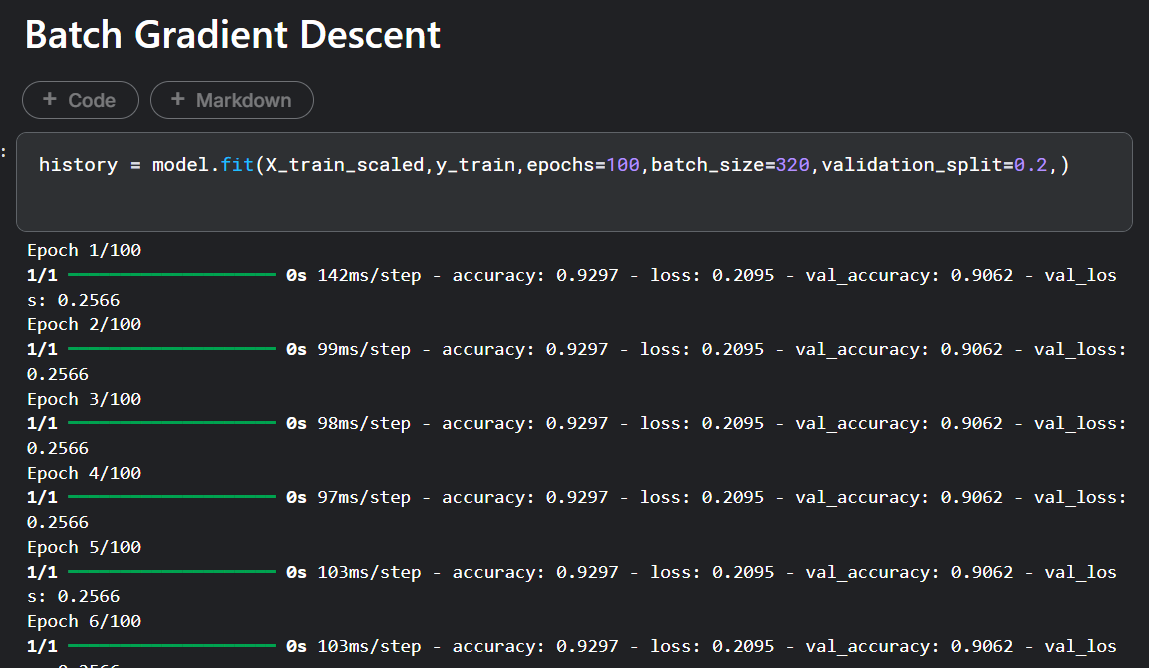

In [145]:
historyb = model.fit(X_train_scaled,y_train,epochs=300,batch_size=320,validation_split=0.2,)
 

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4023 - loss: 0.7209 - val_accuracy: 0.4219 - val_loss: 0.7146
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4023 - loss: 0.7194 - val_accuracy: 0.4375 - val_loss: 0.7131
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4102 - loss: 0.7180 - val_accuracy: 0.4375 - val_loss: 0.7115
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4180 - loss: 0.7166 - val_accuracy: 0.4375 - val_loss: 0.7100
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.4180 - loss: 0.7152 - val_accuracy: 0.4375 - val_loss: 0.7085
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4258 - loss: 0.7138 - val_accuracy: 0.4688 - val_loss: 0.7069
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4336 - loss: 0.7125 - val_accuracy: 0.4688 - val_loss: 0.7055
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4414 - loss: 0.7111 - val_accuracy: 0.4688 - val_loss: 0

# Schotastic Gradient Descent
take one row caluclate loss update do hundered time then move to next one 

In [146]:
historys = model.fit(X_train_scaled,y_train,epochs=300,batch_size=1,validation_split=0.2,)

Epoch 1/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8906 - loss: 0.2931 - val_accuracy: 0.8906 - val_loss: 0.2921
Epoch 2/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9023 - loss: 0.2720 - val_accuracy: 0.9062 - val_loss: 0.2812
Epoch 3/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9141 - loss: 0.2585 - val_accuracy: 0.8906 - val_loss: 0.2736
Epoch 4/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9180 - loss: 0.2520 - val_accuracy: 0.8906 - val_loss: 0.2730
Epoch 5/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.2484 - val_accuracy: 0.8906 - val_loss: 0.2706
Epoch 6/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2435 - val_accuracy: 0.8906 - val_loss: 0.2715
Epoch 7/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.2391 - val_accuracy: 0.9062 - val_loss: 0.2689
Epoch 8/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.2387 - val_accu

# Mini-Batch Gradient Descent
we define batch size means how many row take a one time like we do 100 means 3 update 100 100 100 then 20 , but here is 3 updates not 4 , beacuse keras takes 20% of your 320 rows for validation:

320 × 0.2 = 64 validation rows

320 - 64 = 256 training rows

Now the batches are:

Batch 1 → 100
Batch 2 → 100
Batch 3 → 56

Total    → 256

In [147]:
X_train_scaled.shape

(320, 2)

In [148]:
historym = model.fit(X_train_scaled,y_train,epochs=300,batch_size=100,validation_split=0.2,)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9336 - loss: 0.1866 - val_accuracy: 0.8906 - val_loss: 0.2882
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9375 - loss: 0.1866 - val_accuracy: 0.8906 - val_loss: 0.2883
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1866 - val_accuracy: 0.8906 - val_loss: 0.2883
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9375 - loss: 0.1866 - val_accuracy: 0.8906 - val_loss: 0.2883
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1866 - val_accuracy: 0.8906 - val_loss: 0.2884
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1865 - val_accuracy: 0.8906 - val_loss: 0.2885
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9375 - loss: 0.1865 - val_accuracy: 0.8906 - val_loss: 0.2885
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1865 - val_accuracy: 0.8906 - val_loss:

In [149]:
historys.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

# Graph of all Loss function that how they decrease

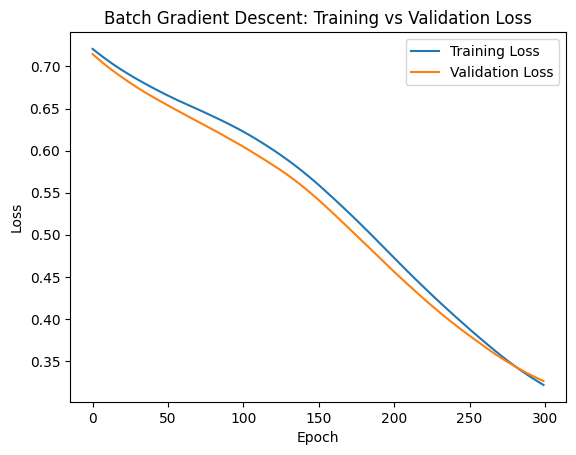

In [150]:
import matplotlib.pyplot as plt

plt.plot(historyb.history['loss'], label='Training Loss')
plt.plot(historyb.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Batch Gradient Descent: Training vs Validation Loss')

plt.legend()
plt.show()

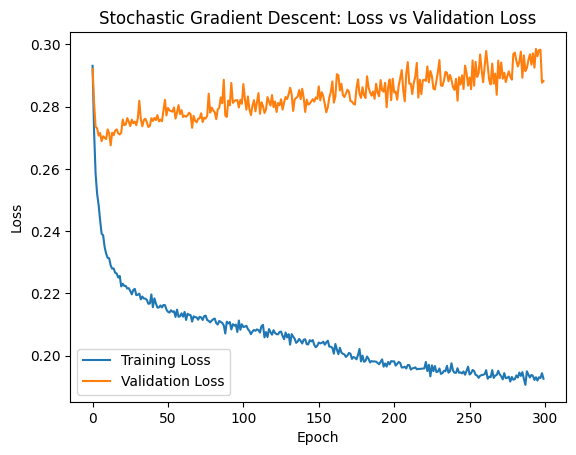

In [151]:
plt.plot(historys.history['loss'], label='Training Loss')
plt.plot(historys.history['val_loss'], label='Validation Loss')

plt.title('Stochastic Gradient Descent: Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

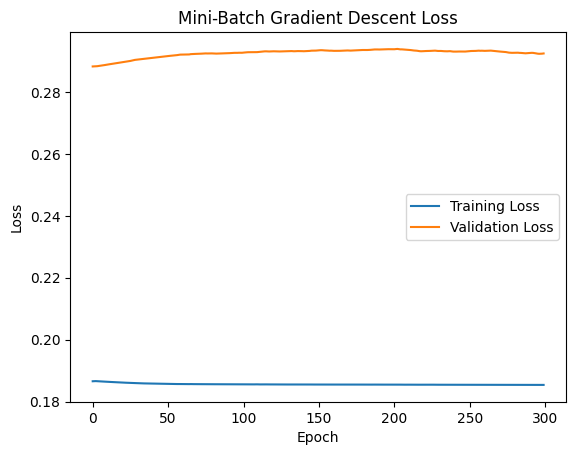

In [152]:
plt.plot(historym.history['loss'], label='Training Loss')
plt.plot(historym.history['val_loss'], label='Validation Loss')

plt.title('Mini-Batch Gradient Descent Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

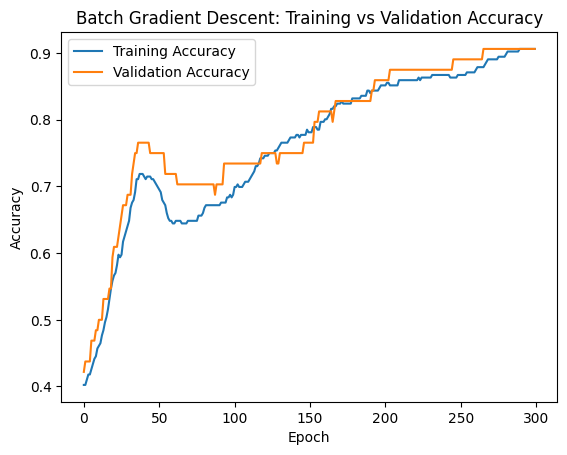

In [153]:

plt.plot(historyb.history['accuracy'], label='Training Accuracy')
plt.plot(historyb.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Batch Gradient Descent: Training vs Validation Accuracy')

plt.legend()
plt.show()

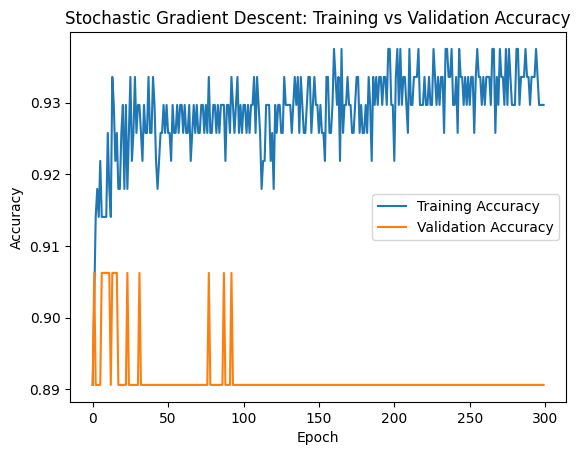

In [154]:
plt.plot(historys.history['accuracy'], label='Training Accuracy')
plt.plot(historys.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stochastic Gradient Descent: Training vs Validation Accuracy')

plt.legend()
plt.show()

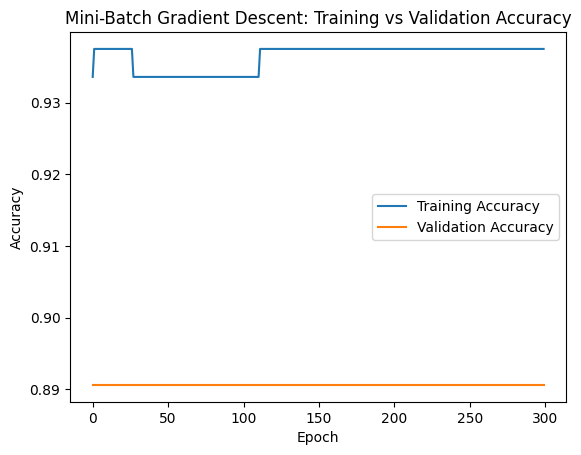

In [155]:
import matplotlib.pyplot as plt

plt.plot(historym.history['accuracy'], label='Training Accuracy')
plt.plot(historym.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Mini-Batch Gradient Descent: Training vs Validation Accuracy')

plt.legend()
plt.show()